In [1]:
import pandas as pd
import numpy as np

In [2]:
%pwd
%cd /home/jovyan/work/results/Cell/
%pwd

/home/jovyan/work/results/Cell


'/home/jovyan/work/results/Cell'

In [3]:
# import the PCC data
pcc_4S = pd.read_csv("pcc_4S.csv", index_col=0)
pcc_I = pd.read_csv("pcc_I.csv", index_col=0)
pcc_III = pd.read_csv("pcc_III.csv", index_col=0)
pcc_IV = pd.read_csv("pcc_IV.csv", index_col=0)
# pcc_NA = pd.read_csv("pcc_NA.csv", index_col=0)
pcc_4S

,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,1.000000,0.101876,-0.105444,0.294110,0.285490,0.043094,0.273760,0.154205,0.535308,0.574785,...,-0.214314,-0.225862,0.491546,0.099288,0.247549,-0.177206,0.227948,-0.268659,0.047149,-0.721479
DPM1,0.101876,1.000000,0.040753,0.366840,0.112091,-0.203120,0.277659,0.230100,0.012097,-0.223822,...,-0.017635,-0.288416,0.410572,0.095112,0.348526,0.411757,-0.319794,-0.130364,0.225836,-0.290486
SCYL3,-0.105444,0.040753,1.000000,0.378629,-0.077102,0.299282,0.164965,0.239981,-0.208912,0.051952,...,0.622151,0.586767,0.021289,0.030100,0.392734,0.130584,0.244455,0.441587,0.019297,0.122590
C1orf112,0.294110,0.366840,0.378629,1.000000,0.090887,0.202204,0.276277,0.408218,-0.028448,0.043607,...,0.243748,0.095764,0.304032,0.119730,0.447024,-0.121551,0.210028,0.290213,-0.177887,-0.509990
FGR,0.285490,0.112091,-0.077102,0.090887,1.000000,-0.117195,0.082018,-0.002028,0.309746,0.378912,...,0.061240,0.080967,0.612712,0.711971,0.284195,0.071398,0.207367,-0.222435,0.442745,-0.239477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,-0.177206,0.411757,0.130584,-0.121551,0.071398,-0.431935,-0.214156,-0.163260,0.100622,-0.076020,...,0.350383,0.075384,0.190224,0.019012,0.208961,1.000000,-0.613841,-0.308633,0.599359,0.277204
CYB561D2,0.227948,-0.319794,0.244455,0.210028,0.207367,0.558621,0.306613,0.189181,0.124066,0.351359,...,0.070697,0.309529,0.159834,0.172155,0.138332,-0.613841,1.000000,0.342137,-0.458748,-0.186283
CCDC7,-0.268659,-0.130364,0.441587,0.290213,-0.222435,0.542627,0.210271,0.254534,-0.347429,-0.078083,...,0.285602,0.507611,-0.117943,-0.003734,0.117266,-0.308633,0.342137,1.000000,-0.371967,0.101145


construct a weighted graph of edges based on 1/abs(PCC-value)

delete rows and columns with Inf entries, since those genes are deleted from the module. (already ensured the genes won't contribute to potential modules candidates by assuring only 1 connected component is >= 3 in the previous graph)

write the function that convertes PCC matrix to distance matrix

In [4]:
import sys
sys.path.append('/home/jovyan/work/FUNCTIONS/')
from methods import Reciprocal_SWIM_pcc_to_distance

In [5]:
%pwd
%cd /home/jovyan/work/parameter_tuning/Reciprocal_SWIM/Cell/
%pwd

/home/jovyan/work/parameter_tuning/Reciprocal_SWIM/Cell


'/home/jovyan/work/parameter_tuning/Reciprocal_SWIM/Cell'

/home/jovyan/work/FUNCTIONS/methods.py:266: RuntimeWarning: divide by zero encountered in divide
  reciprocal = 1 / non_negative_normalized_pcc


IGRAPH UNW- 12939 1322561 -- 
+ attr: name (v), weight (e)
graph is connected: False


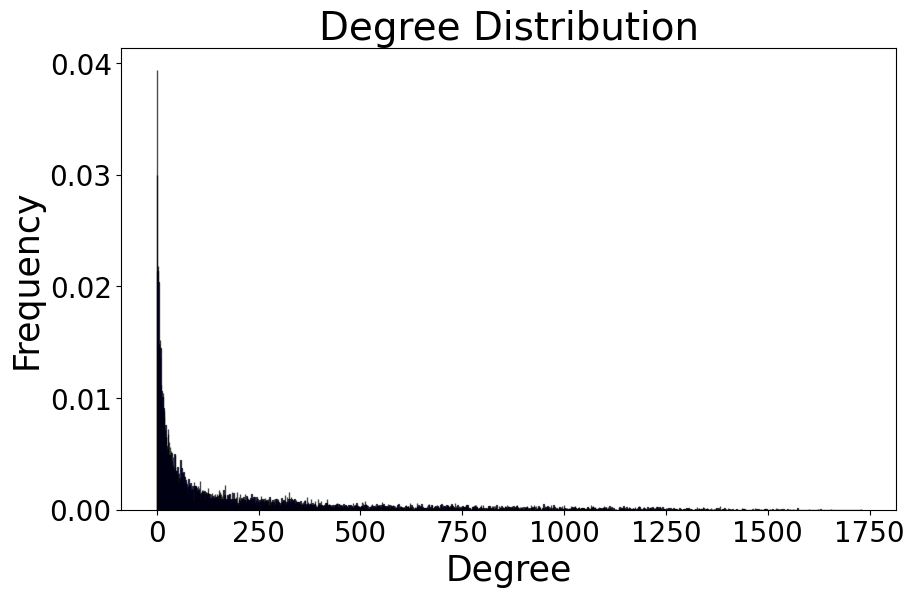

All Pairs Distances:
<class 'list'>
12939X12939


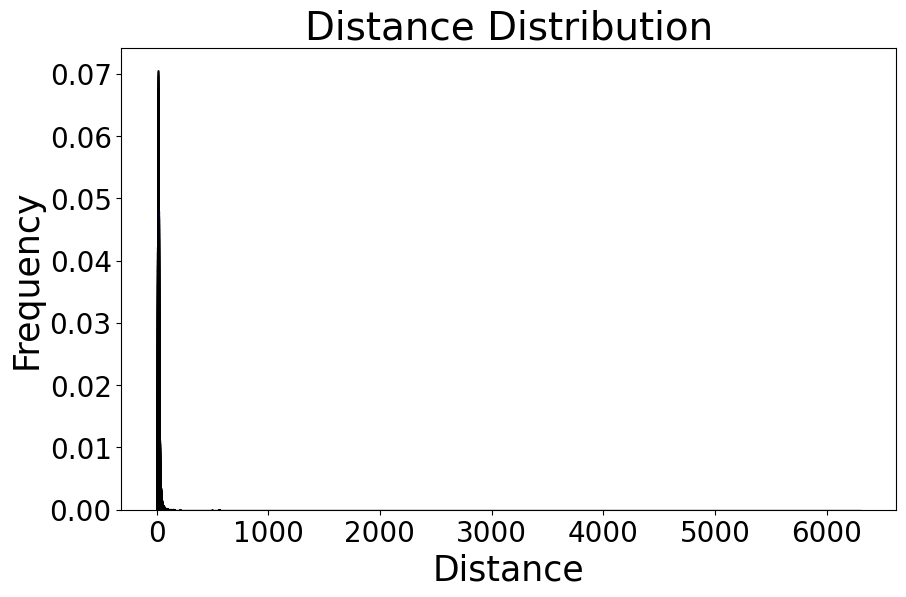

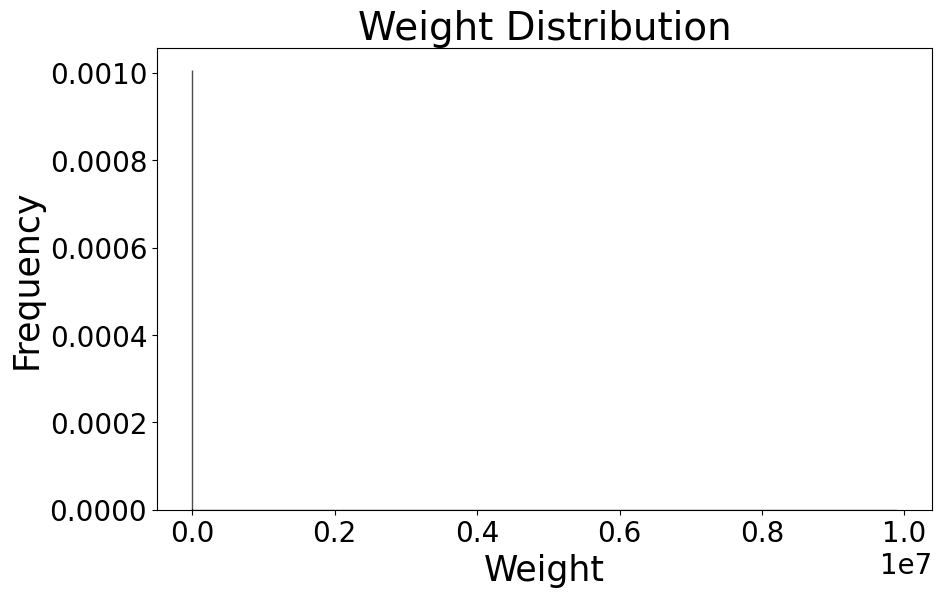

Number of vertices in largest connected component: 12390
Number of edges in largest connected component: 1322541


Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,LINC01176,SEPSECS-AS1,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000000,12.077164,12.114509,10.335746,11.408591,17.414794,10.928387,20.160642,12.992192,14.238769,...,11.234334,3344.686891,11.017135,14.179787,15.253371,11.699586,12.643715,12.121853,17.349253,6.100851
DPM1,12.077164,0.000000,13.671350,9.175476,12.439945,17.244211,9.638019,17.028770,13.515819,14.778353,...,9.928435,3344.269516,11.375174,13.900877,17.299602,9.524999,13.760717,11.217014,14.287347,9.580191
SCYL3,12.114509,13.671350,0.000000,14.081407,13.851651,18.443334,15.959071,22.286147,14.322845,15.966827,...,13.996539,3341.501970,16.167669,17.501007,21.321978,12.324737,16.361050,11.015836,18.235229,9.967081
C1orf112,10.335746,9.175476,14.081407,0.000000,13.429232,13.830080,9.877793,17.806400,15.511089,14.877081,...,6.024495,3346.130812,12.362711,14.950246,15.392861,9.420976,10.703740,9.151178,16.660671,9.317383
FGR,11.408591,12.439945,13.851651,13.429232,0.000000,19.323973,14.024560,23.062989,10.906412,13.322878,...,11.310466,3346.781988,5.056895,5.003783,11.598496,12.384918,13.617459,13.046306,13.475624,11.539570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,11.699586,9.524999,12.324737,9.420976,12.384918,14.043924,9.909928,18.887750,15.369666,14.144558,...,8.427294,3344.327932,12.964717,15.462417,16.209393,0.000000,7.748209,7.756748,10.240646,7.830397
CYB561D2,12.643715,13.760717,16.361050,10.703740,13.617459,14.692915,10.642598,19.862689,15.261860,14.193890,...,9.055569,3348.425541,14.189895,15.971015,16.749304,7.748209,0.000000,8.780349,15.176828,10.814304
CCDC7,12.121853,11.217014,11.015836,9.151178,13.046306,13.085533,9.298407,17.373503,15.695329,14.666443,...,7.419304,3341.331705,13.789397,15.716027,16.587468,7.756748,8.780349,0.000000,14.908387,10.357236


In [6]:
distance_4S = Reciprocal_SWIM_pcc_to_distance(pcc_matrix=pcc_4S, fig_path1="./figures/degree_distribution_4S.svg", fig_path2="./figures/distance_distribution_4S.svg", fig_path3="./figures/weight_distribution_4S.svg", pcc_threshold=0.7)
distance_4S.to_csv("distance_4S.csv")
distance_4S

/home/jovyan/work/FUNCTIONS/methods.py:266: RuntimeWarning: divide by zero encountered in divide
  reciprocal = 1 / non_negative_normalized_pcc


IGRAPH UNW- 12939 1215109 -- 
+ attr: name (v), weight (e)
graph is connected: False


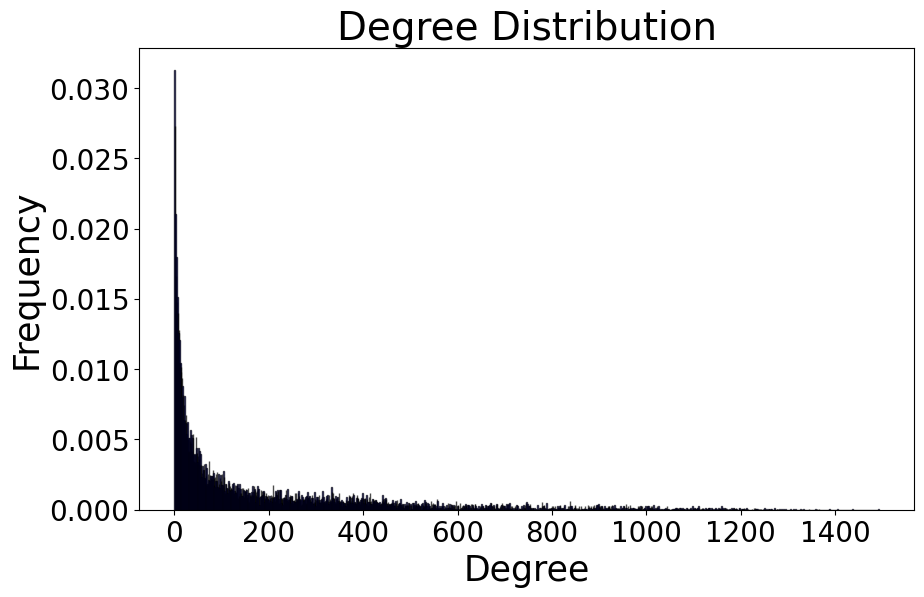

All Pairs Distances:
<class 'list'>
12939X12939


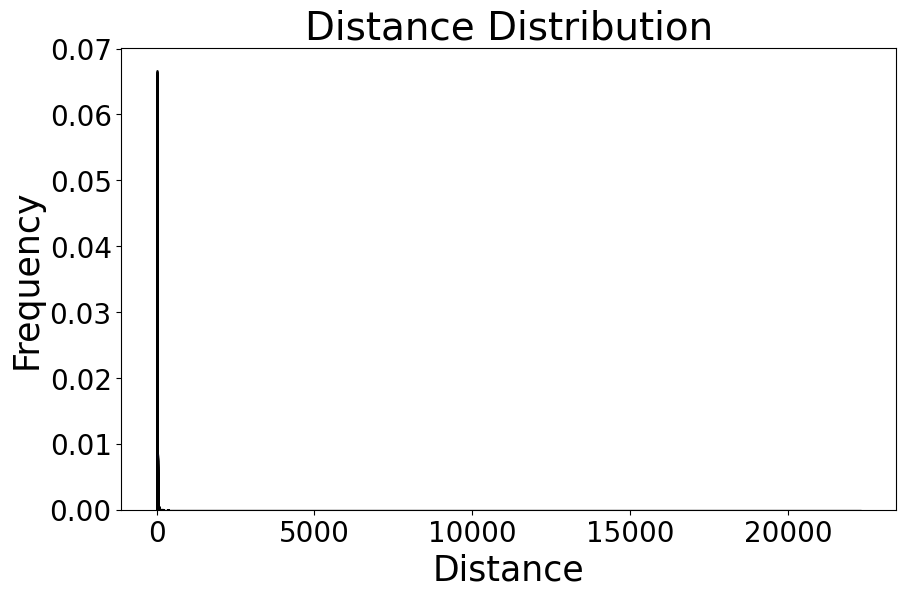

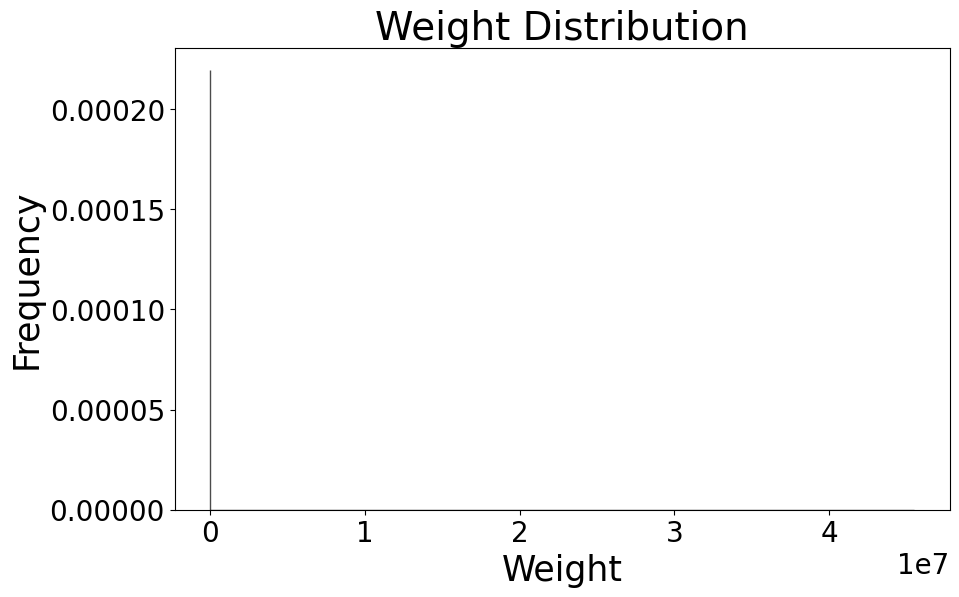

Number of vertices in largest connected component: 12515
Number of edges in largest connected component: 1215099


Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,LINC01176,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000000,20.911603,20.239683,19.481403,15.602511,18.975504,14.176595,14.485504,22.848814,23.529936,...,21.387527,29.758635,15.348049,15.659967,20.496092,18.243819,20.138413,17.118330,20.038849,15.245633
DPM1,20.911603,0.000000,15.117183,7.310219,17.119149,13.556946,12.694354,13.703895,14.181677,14.088975,...,12.533799,30.692454,18.038975,18.261463,15.180190,10.480387,14.226518,11.682629,10.505642,14.689720
SCYL3,20.239683,15.117183,0.000000,12.075571,17.603856,11.941674,11.545974,11.062483,15.856652,16.005796,...,13.144798,25.715961,18.058372,18.313788,14.206323,10.489183,14.219663,10.293315,12.648229,16.717492
C1orf112,19.481403,7.310219,12.075571,0.000000,14.304198,10.450850,10.114902,9.075106,11.140107,10.525579,...,8.197654,27.129057,14.691442,13.043353,12.860972,7.585451,11.642147,9.164697,10.675150,12.471976
FGR,15.602511,17.119149,17.603856,14.304198,0.000000,12.660762,13.937843,15.581417,10.727827,13.105925,...,16.356970,19.114023,3.960275,3.715291,11.181141,7.508877,11.798881,12.263623,8.618284,15.714399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,18.243819,10.480387,10.489183,7.585451,7.508877,6.663897,9.695020,9.361808,5.843828,8.784327,...,10.931242,21.566562,7.963393,9.627306,14.122562,0.000000,5.303265,5.328395,3.688096,9.499866
CYB561D2,20.138413,14.226518,14.219663,11.642147,11.798881,7.621044,12.193787,12.126386,10.899229,12.968314,...,14.893704,25.750549,12.253397,13.917310,18.029484,5.303265,0.000000,8.246326,5.856451,11.811616
CCDC7,17.118330,11.682629,10.293315,9.164697,12.263623,5.082692,9.424819,8.697745,10.400153,13.016095,...,11.531276,23.905487,12.718139,14.382051,14.163522,5.328395,8.246326,0.000000,6.469684,9.877919


In [7]:
distance_I = Reciprocal_SWIM_pcc_to_distance(pcc_matrix=pcc_I, fig_path1="./figures/degree_distribution_I.svg", fig_path2="./figures/distance_distribution_I.svg", fig_path3="./figures/weight_distribution_I.svg", pcc_threshold=0.7)
distance_I.to_csv("distance_I.csv")
distance_I

/home/jovyan/work/FUNCTIONS/methods.py:266: RuntimeWarning: divide by zero encountered in divide
  reciprocal = 1 / non_negative_normalized_pcc


IGRAPH UNW- 12939 1856546 -- 
+ attr: name (v), weight (e)
graph is connected: False


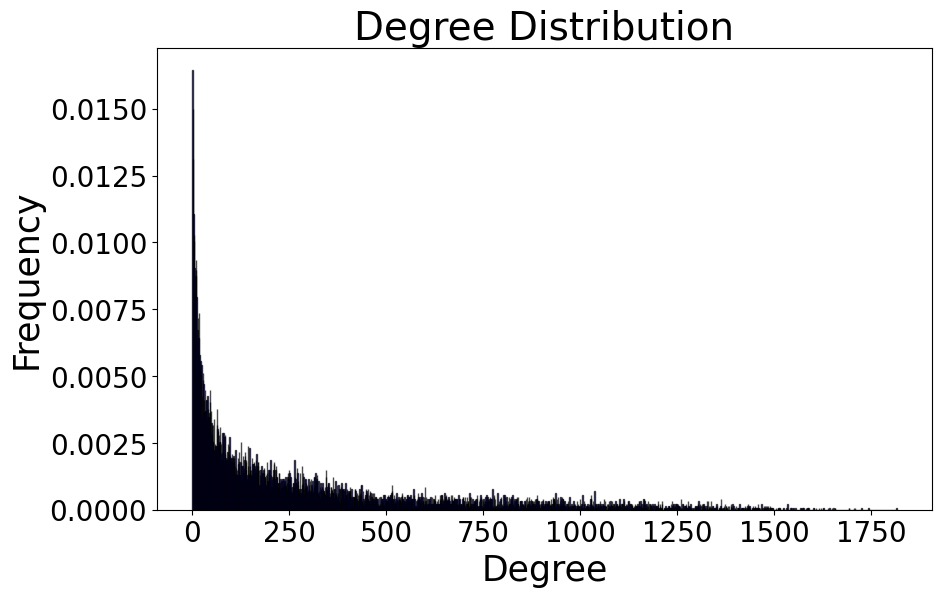

All Pairs Distances:
<class 'list'>
12939X12939


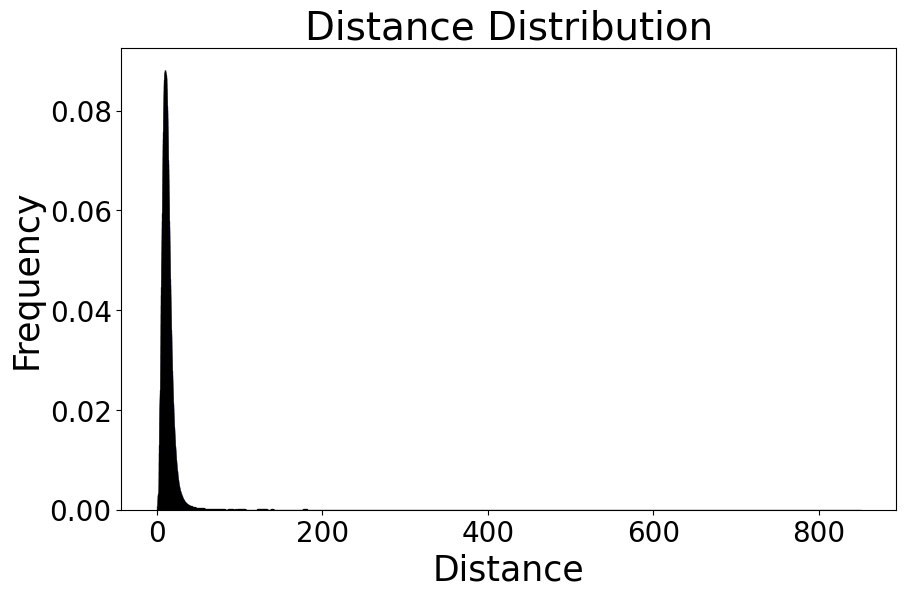

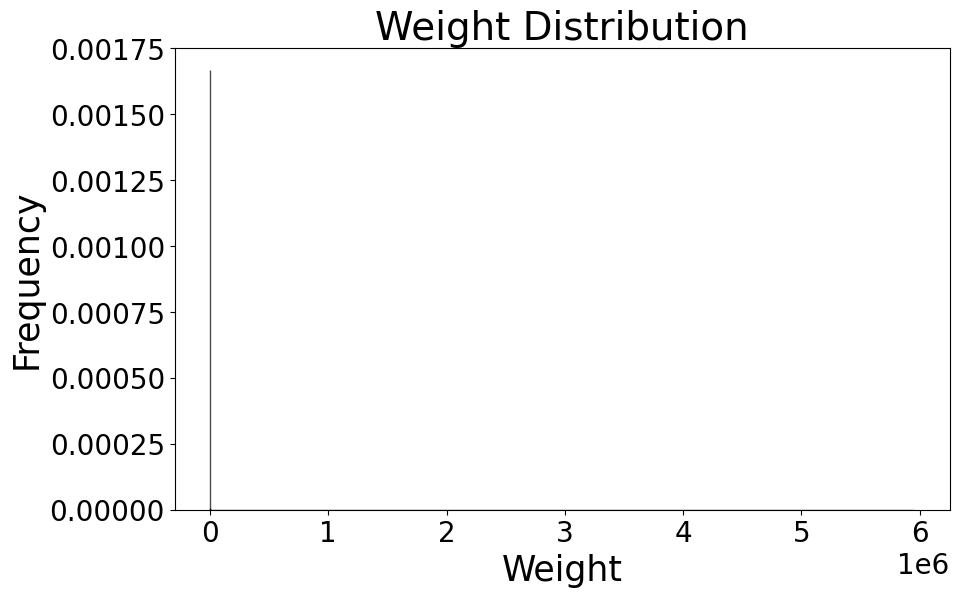

Number of vertices in largest connected component: 12707
Number of edges in largest connected component: 1856535


Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,GCLC,NFYA,STPG1,NIPAL3,LAS1L,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000000,21.449464,8.952872,11.949259,15.096674,11.507086,12.141974,7.358074,7.596289,5.595455,...,28.699480,14.098262,13.839541,15.718462,13.826660,16.646940,41.301683,10.189903,13.762156,10.272364
DPM1,21.449464,0.000000,19.649019,15.375038,25.739586,22.447602,18.071823,20.325945,20.788307,17.955154,...,32.982010,24.515238,23.828837,26.150260,20.359800,27.281880,49.401687,21.808969,25.508249,21.183501
SCYL3,8.952872,19.649019,0.000000,7.404108,11.344295,9.566072,7.678787,10.400650,8.957831,8.205553,...,22.876421,9.535619,9.806790,11.250010,7.919538,13.547469,41.565295,5.455397,11.099629,8.345636
C1orf112,11.949259,15.375038,7.404108,0.000000,14.268127,9.271774,6.904187,11.102703,9.957413,6.737682,...,22.427087,14.283803,11.431077,15.284955,9.898220,17.168150,36.658962,9.287079,14.897841,10.268200
FGR,15.096674,25.739586,11.344295,14.268127,0.000000,14.763119,14.256123,16.252741,15.616835,14.208568,...,30.935234,9.063467,6.589036,5.533516,15.829256,18.513563,41.638839,9.719169,16.976730,11.213513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,16.646940,27.281880,13.547469,17.168150,18.513563,20.316925,16.174219,17.879702,16.674800,15.869117,...,32.182220,19.026921,18.261567,19.403110,18.062553,0.000000,49.156282,15.144462,16.856037,14.392468
CYB561D2,41.301683,49.401687,41.565295,36.658962,41.638839,41.687324,41.759477,40.660988,42.249836,38.488548,...,57.214482,42.428995,37.854577,41.548627,44.684972,49.156282,0.000000,42.313537,47.574872,44.118867
CCDC7,10.189903,21.808969,5.455397,9.287079,9.719169,9.371730,8.852375,10.851351,9.550426,8.807177,...,24.834568,7.606755,7.684566,11.195509,10.515654,15.144462,42.313537,0.000000,12.202998,8.679466


In [8]:
distance_III = Reciprocal_SWIM_pcc_to_distance(pcc_matrix=pcc_III, fig_path1="./figures/degree_distribution_III.svg", fig_path2="./figures/distance_distribution_III.svg", fig_path3="./figures/weight_distribution_III.svg", pcc_threshold=0.7)
distance_III.to_csv("distance_III.csv")
distance_III

/home/jovyan/work/FUNCTIONS/methods.py:266: RuntimeWarning: divide by zero encountered in divide
  reciprocal = 1 / non_negative_normalized_pcc


IGRAPH UNW- 12939 2022063 -- 
+ attr: name (v), weight (e)
graph is connected: False


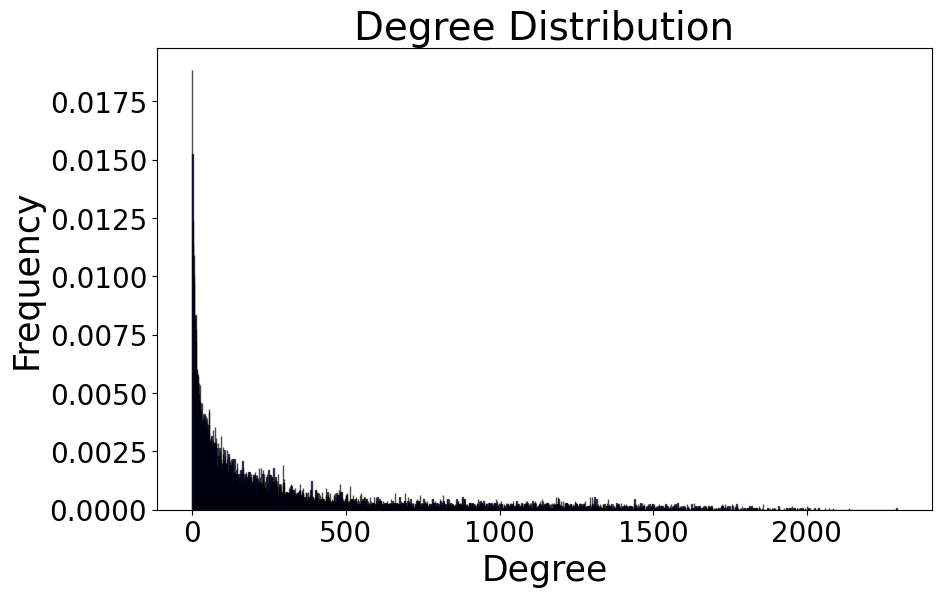

All Pairs Distances:
<class 'list'>
12939X12939


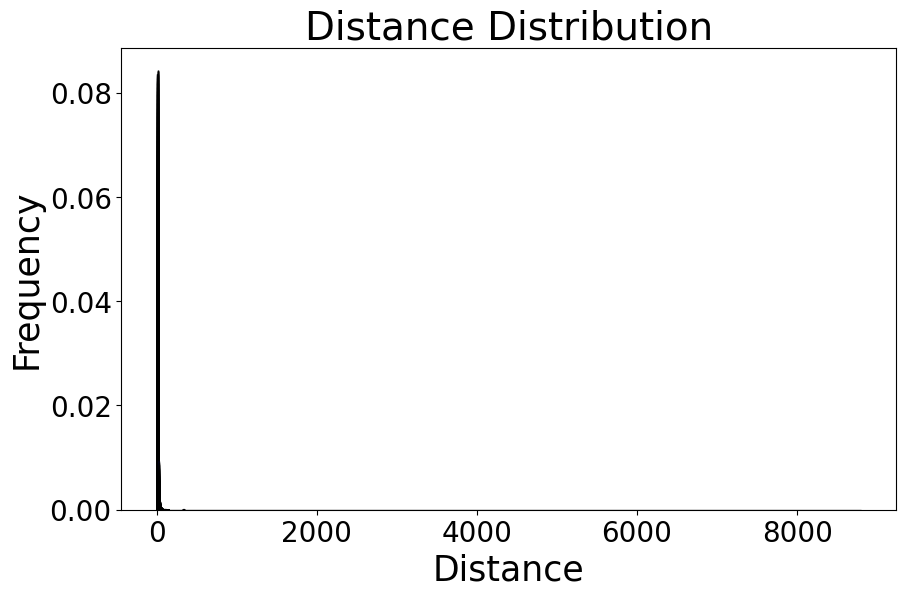

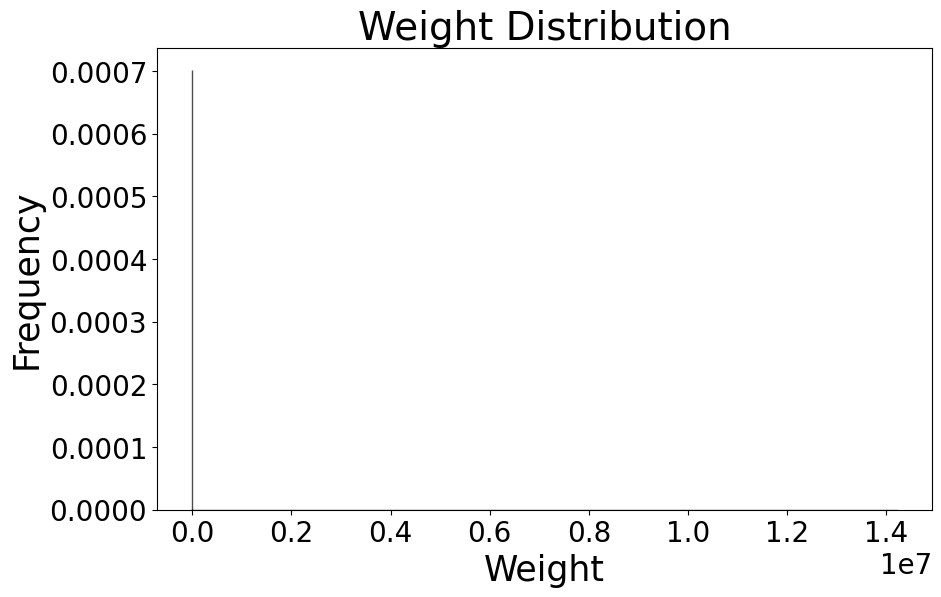

Number of vertices in largest connected component: 12677
Number of edges in largest connected component: 2022053


Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,LAS1L,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000000,12.560726,10.526023,11.454339,15.958799,14.464694,12.612379,9.221837,21.725939,10.801749,...,14.113409,11.510321,18.498227,18.188342,12.206228,11.631616,10.095812,19.840402,12.717575,5.747060
DPM1,12.560726,0.000000,12.369782,10.980945,18.558843,13.565627,12.854990,10.230193,23.365298,11.114991,...,14.752220,16.722888,15.940915,19.552865,13.535014,11.202150,10.961348,24.677205,10.906552,12.610531
SCYL3,10.526023,12.369782,0.000000,7.164782,13.516290,9.929728,7.058625,4.929966,15.103138,5.884282,...,7.443814,10.857147,15.779430,12.770535,7.348550,7.745504,4.956669,19.929213,7.782886,8.870109
C1orf112,11.454339,10.980945,7.164782,0.000000,13.721572,9.366624,6.550667,4.562461,15.893423,3.610843,...,6.947177,12.389460,15.297373,12.215408,7.652666,6.385040,4.676532,19.460124,6.874165,8.514056
FGR,15.958799,18.558843,13.516290,13.721572,0.000000,16.605350,14.119999,11.403019,19.987924,11.297919,...,14.040915,12.423025,13.907886,5.694087,11.703513,12.545116,9.876665,21.436959,12.511494,10.211739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,11.631616,11.202150,7.745504,6.385040,12.545116,9.823044,9.057727,7.042990,15.708998,4.251122,...,10.100883,8.968243,14.902373,11.467987,9.922846,0.000000,3.816931,16.548768,3.396348,5.884556
CYB561D2,10.095812,10.961348,4.956669,4.676532,9.876665,7.405833,6.610069,4.771770,12.475038,2.041198,...,7.055161,10.298336,16.743139,8.799536,8.104292,3.816931,0.000000,17.710123,3.783309,6.878970
CCDC7,19.840402,24.677205,19.929213,19.460124,21.436959,22.786911,21.631815,19.207431,25.292550,18.624066,...,22.035000,13.302117,26.914817,23.661209,20.151238,16.548768,17.710123,0.000000,18.345218,14.093342


In [9]:
distance_IV = Reciprocal_SWIM_pcc_to_distance(pcc_matrix=pcc_IV, fig_path1="./figures/degree_distribution_IV.svg", fig_path2="./figures/distance_distribution_IV.svg", fig_path3="./figures/weight_distribution_IV.svg", pcc_threshold=0.7)
distance_IV.to_csv("distance_IV.csv")
distance_IV